# ۴.۱ تحلیل تک‌متغیره — پیش‌بینی نرخ عدم‌دریافت غذا

**بند WBS:** ۴.۱ (فاز ۴ — کاوش اکتشافی داده)

این نوت‌بوک سه بخش دارد:
- **۴.۱.۱** متغیر هدف $\rho = \text{NoRecv}/\text{Res}$: هیستوگرام/KDE/ECDF/Box-Violin، آماره‌های توصیفی، صدک‌ها، تورم صفر، دو-مُدی بودن، و آزمون برازش در برابر چهار توزیع کاندید (Normal، Beta، Gamma، Log-normal).
- **۴.۱.۲** متغیرهای شمارشی $Res$, $Recv$, $NoRecv$: توزیع، نیاز به تبدیل (log1p/Box-Cox/Yeo-Johnson)، و توزیع اندازه‌ی سلف‌ها.
- **۴.۱.۳** متغیرهای دسته‌ای: فراوانی سلف/وعده/نوع غذا/روز هفته، تشخیص عدم‌توازن، نمودار Pareto.

داده: `data/processed/dataset_v1.csv` (سطح (روز، وعده، سلف، غذا)، ۷٬۵۹۱ ردیف، قفل‌شده در فاز ۳ — فقط‌خواندنی).

خروجی این نوت‌بوک مستقیماً در `doc/eda/round1/S1_univariate.md` به‌صورت یافته‌های کدگذاری‌شده (F1.x) تدوین می‌شود.


In [1]:
import sys
sys.path.insert(0, '/home/mvajhi/code/new_project')

from src.config import set_global_seed, DATA_PROCESSED, FIGURES_DIR
set_global_seed()

from src.viz_fa import setup, fa
setup()

from src.eda_lib.univariate_helpers import (
    descriptive_stats, zero_one_inflation, sarle_bimodality_coefficient,
    kde_peak_count, fit_candidate_distributions, compare_transforms, save_fig,
)

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

RNG = np.random.default_rng(42)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print('setup done; figures dir:', FIGURES_DIR)


setup done; figures dir: /home/mvajhi/code/new_project/reports/figures


In [2]:
df = pd.read_csv(DATA_PROCESSED / 'dataset_v1.csv')
print(df.shape)
df.head(3)


(7591, 22)


,DateReserve,date_gregorian,Meal,RestaurantName,RestaurantType,FoodName,FoodType,Res,Recv,NoRecv,...,DayOfWeek,HolidayInWeekCount,HolidayInPrevWeekCount,HolidayInNextWeekCount,NextHoliday_1,NextHoliday_2,PreviousHoliday_1,PreviousHoliday_2,rho,is_served
0,1402-09-01,2023-11-22,dinner,ابوریحان,daneshgah,خوراک سالاد الویه,khorak,60.0,59.0,1.0,...,4,0,0,0,25,81,50,59,0.016667,True
1,1402-09-01,2023-11-22,dinner,ابوریحان,daneshgah,چلوکباب تابه ای,berenji,96.0,93.0,3.0,...,4,0,0,0,25,81,50,59,0.031250,True
2,1402-09-01,2023-11-22,dinner,ساختمان 6,khabgah,خوراک سالاد الویه,khorak,262.0,245.0,17.0,...,4,0,0,0,25,81,50,59,0.064885,True


## ۴.۱.۱ متغیر هدف $\rho$

### آماره‌های توصیفی و صدک‌ها


In [3]:
rho = df['rho'].to_numpy()

stats_rho = descriptive_stats(rho)
print(f"n = {stats_rho['n']}")
print(f"mean   = {stats_rho['mean']:.4f}")
print(f"median = {stats_rho['median']:.4f}")
print(f"mode   = {stats_rho['mode']:.4f}  (count={stats_rho['mode_count']}, یعنی مد دقیقاً روی صفر است)")
print(f"std    = {stats_rho['std']:.4f}")
print(f"IQR    = {stats_rho['iqr']:.4f}  (Q1={stats_rho['q1']:.4f}, Q3={stats_rho['q3']:.4f})")
print(f"skewness (چولگی)        = {stats_rho['skewness']:.4f}")
print(f"kurtosis excess (کشیدگی) = {stats_rho['kurtosis_excess']:.4f}")
print()
print("صدک‌ها:")
for p, v in stats_rho['percentiles'].items():
    print(f"  p{p:<3} = {v:.4f}")


n = 7591
mean   = 0.0962
median = 0.0800
mode   = 0.0000  (count=373, یعنی مد دقیقاً روی صفر است)
std    = 0.0852
IQR    = 0.0724  (Q1=0.0490, Q3=0.1213)
skewness (چولگی)        = 4.2466
kurtosis excess (کشیدگی) = 33.7914

صدک‌ها:
  p1   = 0.0000
  p5   = 0.0059
  p10  = 0.0238
  p25  = 0.0490
  p50  = 0.0800
  p75  = 0.1213
  p90  = 0.1774
  p95  = 0.2279
  p99  = 0.4000


### تورم صفر و یک (Zero/One-inflation)

In [4]:
infl = zero_one_inflation(rho)
print(f"رکوردهای rho=0 (عدم‌دریافت صفر، سرو کامل): {infl['n_zero']} ({infl['pct_zero']:.2f}%)")
print(f"رکوردهای rho=1 (عدم‌دریافت کامل): {infl['n_one']} ({infl['pct_one']:.2f}%)")
print(f"رکوردهای داخل بازه‌ی باز (0,1): {infl['n_interior']} ({infl['n_interior']/len(rho)*100:.2f}%)")
print()
print("۱۵ رکورد rho=1 (بررسی موردی):")
df[df['rho'] == 1][['DateReserve', 'Meal', 'RestaurantName', 'FoodName', 'Res', 'Recv', 'NoRecv', 'rho']]


رکوردهای rho=0 (عدم‌دریافت صفر، سرو کامل): 373 (4.91%)
رکوردهای rho=1 (عدم‌دریافت کامل): 15 (0.20%)
رکوردهای داخل بازه‌ی باز (0,1): 7203 (94.89%)

۱۵ رکورد rho=1 (بررسی موردی):


,DateReserve,Meal,RestaurantName,FoodName,Res,Recv,NoRecv,rho
1637,1402-10-03,lunch,علوم اجتماعی,خوراک جوجه چینی,235.0,0.0,235.0,1.0
1638,1402-10-03,lunch,علوم اجتماعی,چلو خورش فسنجان,136.0,0.0,136.0,1.0
2251,1402-10-13,lunch,ژئوفیزیک,خوراک کشک بادمجان,10.0,0.0,10.0,1.0
2252,1402-10-13,lunch,ژئوفیزیک,چلو خورش قورمه سبزی,51.0,0.0,51.0,1.0
3876,1402-11-21,dinner,فارابی,چلو خورش قیمه سیب زمینی,49.0,0.0,49.0,1.0
4715,1402-12-09,lunch,علوم و فناوری های میان رشته ای,خوراک کوکو سبزی,4.0,0.0,4.0,1.0
4716,1402-12-09,lunch,علوم و فناوری های میان رشته ای,زرشک پلوبامرغ,90.0,0.0,90.0,1.0
5247,1402-12-21,dinner,کاسپین,چلوکباب کوبیده,9.0,0.0,9.0,1.0
5266,1402-12-21,lunch,علوم اجتماعی,خوراک ماکارونی با قارچ,57.0,0.0,57.0,1.0
5267,1402-12-21,lunch,علوم اجتماعی,چلو خورش کرفس,52.0,0.0,52.0,1.0


### نمودارها: هیستوگرام+KDE، ECDF، Box/Violin

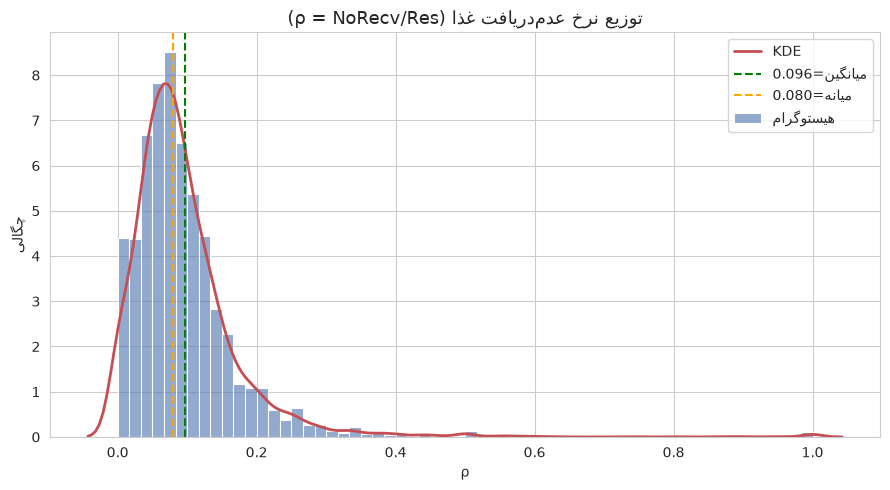

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(rho, bins=60, stat='density', color='#4C72B0', alpha=0.6, ax=ax, label=fa('هیستوگرام'))
sns.kdeplot(rho, color='#C44E52', linewidth=2, ax=ax, label=fa('KDE'))
ax.axvline(stats_rho['mean'], color='green', linestyle='--', linewidth=1.5, label=fa(f"میانگین={stats_rho['mean']:.3f}"))
ax.axvline(stats_rho['median'], color='orange', linestyle='--', linewidth=1.5, label=fa(f"میانه={stats_rho['median']:.3f}"))
ax.set_title(fa('توزیع نرخ عدم‌دریافت غذا (ρ = NoRecv/Res)'), fontsize=13)
ax.set_xlabel(fa('ρ'))
ax.set_ylabel(fa('چگالی'))
ax.legend()
fig.tight_layout()
save_fig(fig, '4.1_rho_histogram_kde.png', FIGURES_DIR)
plt.show()


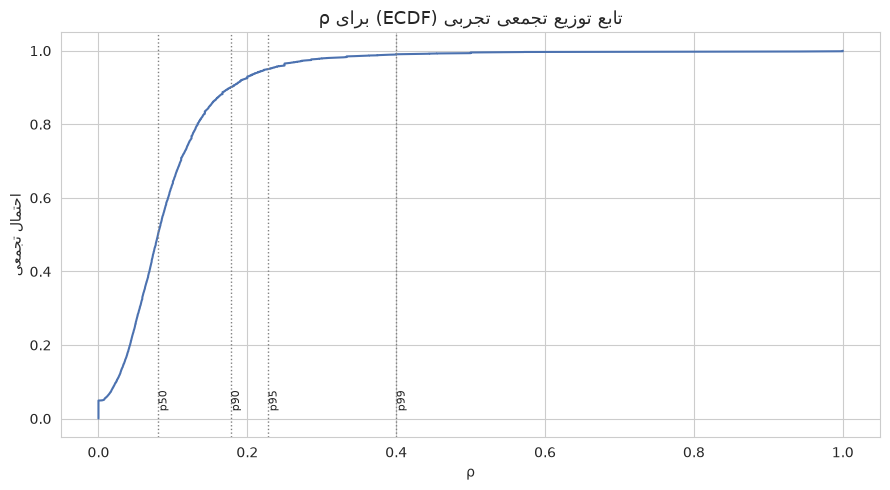

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
x_sorted = np.sort(rho)
y_ecdf = np.arange(1, len(x_sorted) + 1) / len(x_sorted)
ax.plot(x_sorted, y_ecdf, color='#4C72B0', linewidth=1.5)
for p in [50, 90, 95, 99]:
    v = stats_rho['percentiles'][p]
    ax.axvline(v, color='gray', linestyle=':', linewidth=1)
    ax.text(v, 0.02, fa(f'p{p}'), rotation=90, fontsize=8, va='bottom')
ax.set_title(fa('تابع توزیع تجمعی تجربی (ECDF) برای ρ'), fontsize=13)
ax.set_xlabel(fa('ρ'))
ax.set_ylabel(fa('احتمال تجمعی'))
fig.tight_layout()
save_fig(fig, '4.1_rho_ecdf.png', FIGURES_DIR)
plt.show()


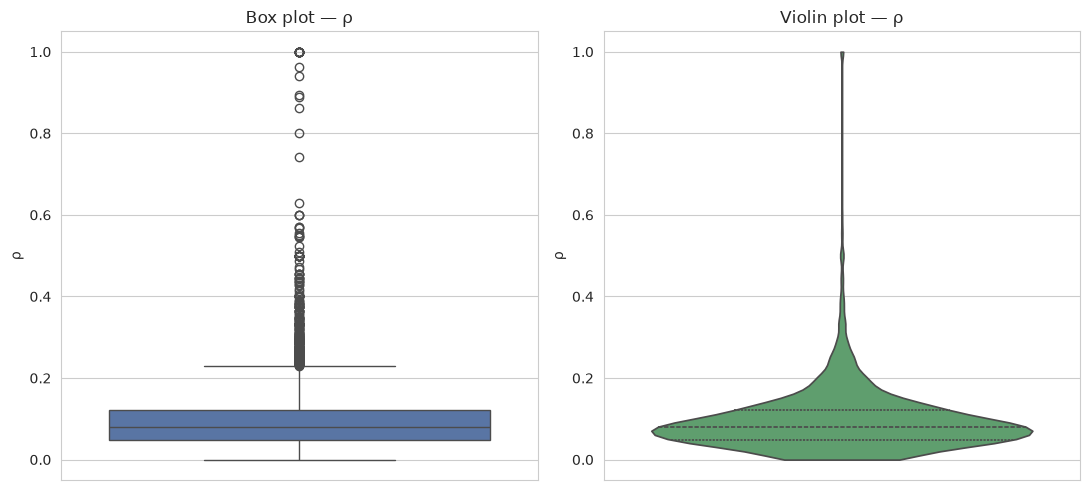

تعداد نقاط خارج از حصار IQR×1.5 (پرت به تعریف Tukey): 372 (4.90%)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sns.boxplot(y=rho, ax=axes[0], color='#4C72B0')
axes[0].set_title(fa('Box plot — ρ'), fontsize=12)
axes[0].set_ylabel(fa('ρ'))

sns.violinplot(y=rho, ax=axes[1], color='#55A868', inner='quartile', cut=0)
axes[1].set_title(fa('Violin plot — ρ'), fontsize=12)
axes[1].set_ylabel(fa('ρ'))

fig.tight_layout()
save_fig(fig, '4.1_rho_box_violin.png', FIGURES_DIR)
plt.show()

n_outliers_iqr = ((rho < stats_rho['q1'] - 1.5*stats_rho['iqr']) | (rho > stats_rho['q3'] + 1.5*stats_rho['iqr'])).sum()
print(f"تعداد نقاط خارج از حصار IQR×1.5 (پرت به تعریف Tukey): {n_outliers_iqr} ({n_outliers_iqr/len(rho)*100:.2f}%)")


### آیا $\rho$ دو-مُدی است؟

دو معیار مکمل: (۱) شمارش قله‌های KDE روی شبکه‌ی چگالی، (۲) ضریب دومُدی بودن Sarle (اگر > ۰.۵۵۵ نشانه‌ی احتمال دومُدی است، با مرجع توزیع یکنواخت).

In [8]:
peak_xs, peak_ys = kde_peak_count(rho)
print(f"تعداد قله‌های KDE: {len(peak_xs)}")
for x, y in zip(peak_xs, peak_ys):
    print(f"  x={x:.4f}  density={y:.4f}")

bc = sarle_bimodality_coefficient(rho)
print(f"\nضریب دومُدی بودن Sarle = {bc:.4f}  (آستانه‌ی مرجع ۰.۵۵۵)")
print("نتیجه:", "احتمال دومُدی بودن" if bc > 0.555 else "دومُدی نیست (تک‌مُدی با چولگی شدید)")


تعداد قله‌های KDE: 9
  x=0.0690  density=7.8229
  x=0.3297  density=0.1447
  x=0.3757  density=0.0845
  x=0.4412  density=0.0460
  x=0.4997  density=0.0695
  x=0.5538  density=0.0234
  x=0.7414  density=0.0037
  x=0.7999  density=0.0037
  x=0.8894  density=0.0078

ضریب دومُدی بودن Sarle = 0.4783  (آستانه‌ی مرجع ۰.۵۵۵)
نتیجه: دومُدی نیست (تک‌مُدی با چولگی شدید)


قله‌های فرعی که KDE در دنباله‌ی راست پیدا می‌کند از تُنُکی داده در آن ناحیه ناشی می‌شوند (نویز باندویدث)، نه یک رژیم رفتاری دوم واقعی — ضریب Sarle این را روشن می‌کند.

### آزمون‌های نکویی برازش (Goodness-of-Fit)

چهار توزیع کاندید: Normal، Beta، Gamma، Log-normal. چون $\rho \in [0,1]$ و ۳۷۳ رکورد دقیقاً روی صفر و ۱۵ رکورد دقیقاً روی یک هستند، برازش MLE مستقیم Beta/Gamma/Log-normal روی این نقاط مرزی نامعتبر می‌شود؛ دو حالت گزارش می‌شود:
1. **کل داده** با اصلاح مرزی (تبدیل Smithson–Verkuilen برای Beta، epsilon-shift برای Gamma/Log-normal) — می‌سنجد که تورم صفر/یک چقدر برازش را خراب می‌کند.
2. **فقط بازه‌ی باز (۰,۱)** — می‌سنجد که «شکل» توزیع (جدا از تورم مرزی) به کدام توزیع نزدیک‌تر است.

برای Shapiro-Wilk، چون n=7591 > 5000 (محدودیت دقت این آزمون)، روی یک نمونه‌ی تصادفی ۵۰۰۰تایی (seed=42) اجرا می‌شود؛ Anderson-Darling و KS روی کل داده اجرا می‌شوند.

In [9]:
# Shapiro-Wilk روی نمونه‌ی ۵۰۰۰تایی
sub_idx = RNG.choice(len(rho), 5000, replace=False)
sh = stats.shapiro(rho[sub_idx])
print(f"Shapiro-Wilk (subsample n=5000): W={sh.statistic:.4f}, p={sh.pvalue:.3e}")

# Anderson-Darling در برابر Normal (کل داده)
ad = stats.anderson(rho, dist='norm')
print(f"\nAnderson-Darling vs Normal: statistic={ad.statistic:.2f}")
print(f"  مقادیر بحرانی در سطوح {list(ad.significance_level)}: {list(np.round(ad.critical_values, 3))}")
print(f"  statistic >> بزرگ‌ترین مقدار بحرانی → رد قطعی نرمال بودن در سطح ۱٪")


Shapiro-Wilk (subsample n=5000): W=0.7114, p=1.021e-68

Anderson-Darling vs Normal: statistic=351.49
  مقادیر بحرانی در سطوح [np.float64(15.0), np.float64(10.0), np.float64(5.0), np.float64(2.5), np.float64(1.0)]: [np.float64(0.561), np.float64(0.631), np.float64(0.752), np.float64(0.873), np.float64(1.035)]
  statistic >> بزرگ‌ترین مقدار بحرانی → رد قطعی نرمال بودن در سطح ۱٪


/tmp/ipykernel_427340/69467808.py:7: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad = stats.anderson(rho, dist='norm')


In [10]:
print("=== KS در برابر ۴ توزیع کاندید — کل داده (با اصلاح مرزی) ===")
fit_full = fit_candidate_distributions(rho, interior_only=False)
display(fit_full[['dist', 'params', 'ks_stat', 'ks_pvalue']])

print("\n=== KS در برابر ۴ توزیع کاندید — فقط بازه‌ی باز (۰,۱) ===")
fit_interior = fit_candidate_distributions(rho, interior_only=True)
display(fit_interior[['dist', 'params', 'ks_stat', 'ks_pvalue']])

best_full = fit_full.loc[fit_full['ks_stat'].idxmin(), 'dist']
best_interior = fit_interior.loc[fit_interior['ks_stat'].idxmin(), 'dist']
print(f"\nکمترین KS-statistic (بهترین برازش) روی کل داده: {best_full}")
print(f"کمترین KS-statistic (بهترین برازش) روی بازه‌ی باز: {best_interior}")


=== KS در برابر ۴ توزیع کاندید — کل داده (با اصلاح مرزی) ===


,dist,params,ks_stat,ks_pvalue
0,Normal,"mu=0.0962, sigma=0.0852",0.139643,1.342671e-129
1,Beta,"a=0.8209, b=6.7666",0.144382,1.482791e-138
2,Gamma,"a=0.7991, scale=0.1204",0.203328,1.261687e-275
3,Log-normal,"s=2.5340, scale=0.0458",0.307628,0.000000e+00



=== KS در برابر ۴ توزیع کاندید — فقط بازه‌ی باز (۰,۱) ===


,dist,params,ks_stat,ks_pvalue
0,Normal,"mu=0.0993, sigma=0.0739",0.132061,5.325311e-110
1,Beta,"a=2.0207, b=17.9783",0.061469,4.209182e-24
2,Gamma,"a=2.3730, scale=0.0419",0.042849,6.270177e-12
3,Log-normal,"s=0.6939, scale=0.0793",0.048295,4.865661e-15



کمترین KS-statistic (بهترین برازش) روی کل داده: Normal
کمترین KS-statistic (بهترین برازش) روی بازه‌ی باز: Gamma


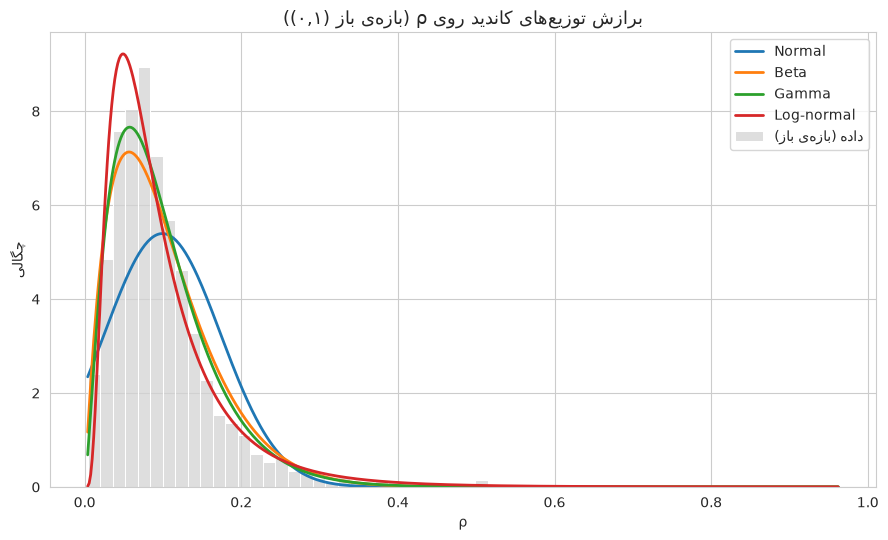

In [11]:
# نمودار تطبیق بصری: هیستوگرام بازه‌ی باز + PDF چهار توزیع برازش‌شده
interior = rho[(rho > 0) & (rho < 1)]
a_b, b_b, _, _ = stats.beta.fit(interior, floc=0, fscale=1)
mean_i, std_i = np.mean(interior), np.std(interior, ddof=1)
a_g, loc_g, scale_g = stats.gamma.fit(interior, floc=0)
s_l, loc_l, scale_l = stats.lognorm.fit(interior, floc=0)

xs = np.linspace(interior.min(), interior.max(), 500)
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.histplot(interior, bins=60, stat='density', color='lightgray', ax=ax, label=fa('داده (بازه‌ی باز)'))
ax.plot(xs, stats.norm(mean_i, std_i).pdf(xs), label='Normal', linewidth=2)
ax.plot(xs, stats.beta(a_b, b_b).pdf(xs), label='Beta', linewidth=2)
ax.plot(xs, stats.gamma(a_g, loc_g, scale_g).pdf(xs), label='Gamma', linewidth=2)
ax.plot(xs, stats.lognorm(s_l, loc_l, scale_l).pdf(xs), label='Log-normal', linewidth=2)
ax.set_title(fa('برازش توزیع‌های کاندید روی ρ (بازه‌ی باز (۰,۱))'), fontsize=13)
ax.set_xlabel(fa('ρ'))
ax.set_ylabel(fa('چگالی'))
ax.legend()
fig.tight_layout()
save_fig(fig, '4.1_rho_distribution_fits.png', FIGURES_DIR)
plt.show()


### جمع‌بندی ۴.۱.۱

انتظار سند پروژه («$\rho$ توزیع Beta-مانند و راست‌چوله با تورم صفر») به‌طور **جزئی** تأیید می‌شود:
- تورم صفر واقعی و قابل‌توجه است (خروجی کد بالا).
- چولگی و کشیدگی به‌شدت بالا هستند (خروجی کد بالا) — دُم راست بسیار سنگین.
- روی کل داده، به‌دلیل n بزرگ (۷۵۹۱) آزمون KS هر ۴ توزیع کاندید را در سطح ۰.۰۵ رد می‌کند (p<0.001 برای همه — KS با n بزرگ بیش‌ازحد قدرتمند/حساس می‌شود)، اما **رتبه‌بندی نسبی** KS-statistic بین توزیع‌ها همچنان برای انتخاب مدل معنادار است.
- روی بازه‌ی باز (بدون نقاط مرزی ۰/۱)، Beta و Gamma به‌وضوح به داده نزدیک‌تر از Normal هستند (خروجی کد بالا) — این نتیجه مستقیماً از انتخاب Beta regression یا Binomial GLM (به‌جای رگرسیون خطی ساده) در فاز ۷ پشتیبانی می‌کند، به‌شرط مدل‌سازی جداگانه‌ی تورم صفر (مثلاً zero-inflated Beta یا two-part model).

## ۴.۱.۲ متغیرهای شمارشی — $Res$, $Recv$, $NoRecv$

In [12]:
count_vars = ['Res', 'Recv', 'NoRecv']
summary_rows = []
for col in count_vars:
    x = df[col].to_numpy(dtype=float)
    summary_rows.append({
        'variable': col, 'min': x.min(), 'max': x.max(), 'mean': x.mean(),
        'median': np.median(x), 'std': x.std(ddof=1), 'skewness': stats.skew(x),
        'n_zero': int((x == 0).sum()),
    })
count_summary = pd.DataFrame(summary_rows)
display(count_summary)


,variable,min,max,mean,median,std,skewness,n_zero
0,Res,4.0,1958.0,265.927019,154.0,301.810209,2.006975,0
1,Recv,0.0,1903.0,244.520617,140.0,282.767041,2.081386,15
2,NoRecv,0.0,527.0,21.406402,13.0,25.388194,3.096864,373


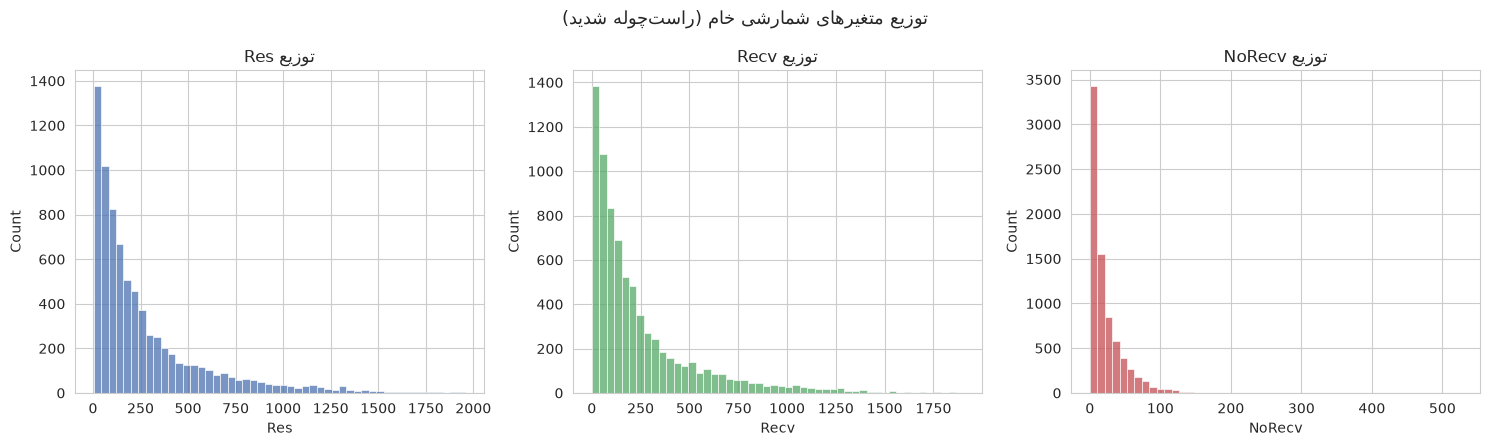

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = ['#4C72B0', '#55A868', '#C44E52']
for ax, col, c in zip(axes, count_vars, colors):
    sns.histplot(df[col], bins=50, color=c, ax=ax)
    ax.set_title(fa(f'توزیع {col}'), fontsize=12)
    ax.set_xlabel(col)
fig.suptitle(fa('توزیع متغیرهای شمارشی خام (راست‌چوله شدید)'), fontsize=13)
fig.tight_layout()
save_fig(fig, '4.1_count_vars_raw.png', FIGURES_DIR)
plt.show()


### مقایسه‌ی تبدیل‌ها (log1p / Box-Cox / Yeo-Johnson)

معیار: آماره‌ی Anderson-Darling در برابر Normal پس از تبدیل (کمتر = نزدیک‌تر به نرمال). Box-Cox فقط وقتی متغیر کاملاً مثبت باشد قابل‌اجراست؛ $Recv$ و $NoRecv$ مقدار صفر دارند پس ردیف Box-Cox آن‌ها N/A است (این خودش یک محدودیت عملی مهم Box-Cox برای این داده است).

In [14]:
transform_results = {}
for col in count_vars:
    x = df[col].to_numpy(dtype=float)
    res = compare_transforms(x)
    res.insert(0, 'variable', col)
    transform_results[col] = res
    print(f"--- {col} ---")
    display(res)


--- Res ---


/home/mvajhi/code/new_project/src/eda_lib/univariate_helpers.py:145: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_raw = stats.anderson(x, dist="norm")
/home/mvajhi/code/new_project/src/eda_lib/univariate_helpers.py:150: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `meth

,variable,transform,lambda,skewness,ad_stat
0,Res,raw,NaN,2.006975,540.129306
1,Res,log1p,NaN,-0.393973,23.151850
2,Res,Box-Cox,0.141696,-0.030518,4.667476
3,Res,Yeo-Johnson,0.129658,-0.028947,5.371651


--- Recv ---


/home/mvajhi/code/new_project/src/eda_lib/univariate_helpers.py:145: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_raw = stats.anderson(x, dist="norm")
/home/mvajhi/code/new_project/src/eda_lib/univariate_helpers.py:150: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `meth

,variable,transform,lambda,skewness,ad_stat
0,Recv,raw,NaN,2.081386,554.196080
1,Recv,log1p,NaN,-0.483233,25.778709
2,Recv,Box-Cox,NaN,NaN,NaN
3,Recv,Yeo-Johnson,0.143455,-0.027376,3.937444


--- NoRecv ---


/home/mvajhi/code/new_project/src/eda_lib/univariate_helpers.py:145: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_raw = stats.anderson(x, dist="norm")
/home/mvajhi/code/new_project/src/eda_lib/univariate_helpers.py:150: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `meth

,variable,transform,lambda,skewness,ad_stat
0,NoRecv,raw,NaN,3.096864,487.974313
1,NoRecv,log1p,NaN,-0.256305,33.782892
2,NoRecv,Box-Cox,NaN,NaN,NaN
3,NoRecv,Yeo-Johnson,0.09851,-0.026559,21.434399


### توزیع اندازه‌ی سلف‌ها (میانگین Res به تفکیک سلف)

تعداد سلف: 32
میانگین Res بزرگ‌ترین سلف (فنی امیرآباد): 755.7
میانگین Res کوچک‌ترین سلف (دوره حوزه علوم انسانی): 15.8
نسبت بزرگ‌ترین به کوچک‌ترین: 47.8x
چولگی توزیع میانگین Res بین سلف‌ها: 1.071


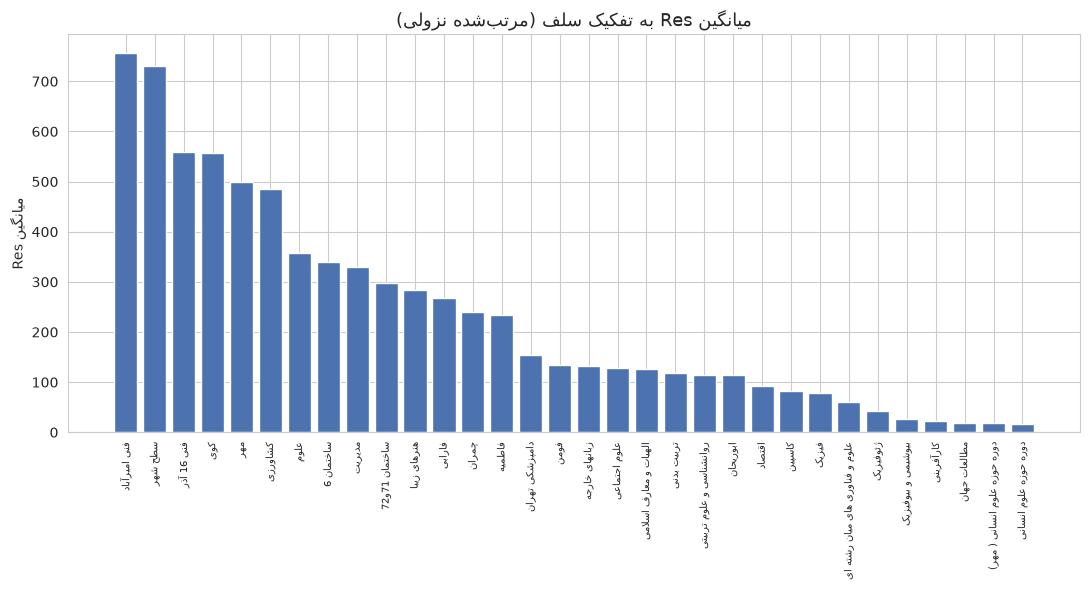

In [15]:
rest_mean_res = df.groupby('RestaurantName')['Res'].mean().sort_values(ascending=False)
print(f"تعداد سلف: {len(rest_mean_res)}")
print(f"میانگین Res بزرگ‌ترین سلف ({rest_mean_res.index[0]}): {rest_mean_res.iloc[0]:.1f}")
print(f"میانگین Res کوچک‌ترین سلف ({rest_mean_res.index[-1]}): {rest_mean_res.iloc[-1]:.1f}")
print(f"نسبت بزرگ‌ترین به کوچک‌ترین: {rest_mean_res.iloc[0]/rest_mean_res.iloc[-1]:.1f}x")
print(f"چولگی توزیع میانگین Res بین سلف‌ها: {stats.skew(rest_mean_res.values):.3f}")

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(range(len(rest_mean_res)), rest_mean_res.values, color='#4C72B0')
ax.set_xticks(range(len(rest_mean_res)))
ax.set_xticklabels([fa(n) for n in rest_mean_res.index], fontsize=7, rotation=90)
ax.set_title(fa('میانگین Res به تفکیک سلف (مرتب‌شده نزولی)'), fontsize=13)
ax.set_ylabel(fa('میانگین Res'))
fig.tight_layout()
save_fig(fig, '4.1_restaurant_size_distribution.png', FIGURES_DIR)
plt.show()


### جمع‌بندی ۴.۱.۲

هر سه متغیر شمارشی راست‌چوله شدید هستند (خروجی کد بالا). برای $Res$ (کاملاً مثبت)، Box-Cox و Yeo-Johnson تقریباً هم‌تراز و به‌مراتب بهتر از log1p عمل می‌کنند. برای $Recv$/$NoRecv$ که مقدار صفر دارند، Box-Cox اصلاً قابل‌اجرا نیست و Yeo-Johnson تنها گزینه‌ی پارامتری معقول است؛ با این‌حال حتی بعد از Yeo-Johnson، $NoRecv$ (که ۳۷۳ صفر دارد) به‌خوبی $Res$/$Recv$ نرمال نمی‌شود — نشانه‌ی دیگری از ماهیت شمارشی/تورم‌صفر این متغیر که برای مدل‌سازی $\rho$ باید در نظر گرفته شود (نه صرفاً یک تبدیل واحد برای کل خط‌لوله).

اندازه‌ی سلف‌ها (میانگین Res) به‌وضوح ناهمگن است — نسبت بزرگ‌ترین به کوچک‌ترین چند ده برابر (خروجی کد بالا). این خودش هشداری برای بند ۴.۸ (ناهم‌واریانسی نسبت به Res) و بند ۴.۶.۴ (تصمیم global vs per-cluster) است.

## ۴.۱.۳ متغیرهای دسته‌ای

In [16]:
print("=== فراوانی سلف (RestaurantName) ===")
rest_counts = df['RestaurantName'].value_counts()
display(rest_counts)

print(f"\nتعداد کل سلف: {len(rest_counts)}")
print(f"سلف‌های با کمتر از ۳۰ رکورد: {(rest_counts < 30).sum()}")
print(rest_counts[rest_counts < 30])


=== فراوانی سلف (RestaurantName) ===


RestaurantName
فاطمیه                            480
کوی                               480
فارابی                            479
ابوریحان                          450
کشاورزی                           337
فومن                              333
کاسپین                            314
سطح شهر                           310
چمران                             282
ساختمان 71و72                     270
ساختمان 6                         258
مهر                               198
هنرهای زیبا                       198
فنی امیرآباد                      198
فنی 16 آذر                        198
علوم                              198
علوم اجتماعی                      197
مدیریت                            197
روانشناسی و علوم تربیتی           197
دامپزشکی تهران                    195
علوم و فناوری های میان رشته ای    192
تربیت بدنی                        192
الهیات و معارف اسلامی             191
فیزیک                             190
اقتصاد                            188
بیوشیمی و بیوفیزیک                1


تعداد کل سلف: 32
سلف‌های با کمتر از ۳۰ رکورد: 2
RestaurantName
دوره حوزه علوم انسانی ( مهر)    7
دوره حوزه علوم انسانی           5
Name: count, dtype: int64


In [17]:
print("=== فراوانی وعده (Meal) ===")
meal_counts = df['Meal'].value_counts()
print(meal_counts)
print(f"نسبت ناهار به شام: {meal_counts['lunch']/meal_counts['dinner']:.2f} : 1")
print(f"تعداد روزهای یکتا با ناهار: {df[df['Meal']=='lunch']['DateReserve'].nunique()}")
print(f"تعداد روزهای یکتا با شام:   {df[df['Meal']=='dinner']['DateReserve'].nunique()}")

print("\n=== فراوانی نوع غذا (FoodType) ===")
print(df['FoodType'].value_counts())

print("\n=== فراوانی نوع سلف (RestaurantType) ===")
print(df['RestaurantType'].value_counts())

print("\n=== جدول متقاطع Meal × RestaurantType ===")
ct = pd.crosstab(df['Meal'], df['RestaurantType'])
display(ct)
print("(نکته: دانشگاهی‌ها عمدتاً ناهار، خوابگاهی‌ها عمدتاً شام سرو می‌کنند)")

print("\n=== فراوانی روز هفته (DayOfWeek، ۰=شنبه..۶=جمعه) ===")
dow_map = {0: 'شنبه', 1: 'یکشنبه', 2: 'دوشنبه', 3: 'سه‌شنبه', 4: 'چهارشنبه', 5: 'پنجشنبه', 6: 'جمعه'}
dow_counts = df['DayOfWeek'].value_counts().sort_index()
dow_table = pd.DataFrame({'روز': [dow_map[i] for i in dow_counts.index], 'تعداد': dow_counts.values,
                           'درصد': (dow_counts.values / dow_counts.sum() * 100).round(2)})
display(dow_table)


=== فراوانی وعده (Meal) ===
Meal
lunch     5426
dinner    2165
Name: count, dtype: int64
نسبت ناهار به شام: 2.51 : 1
تعداد روزهای یکتا با ناهار: 128
تعداد روزهای یکتا با شام:   137

=== فراوانی نوع غذا (FoodType) ===
FoodType
berenji    3891
khorak     3700
Name: count, dtype: int64

=== فراوانی نوع سلف (RestaurantType) ===
RestaurantType
daneshgah    4900
khabgah      2691
Name: count, dtype: int64

=== جدول متقاطع Meal × RestaurantType ===


RestaurantType,daneshgah,khabgah
Meal,,
dinner,205,1960
lunch,4695,731


(نکته: دانشگاهی‌ها عمدتاً ناهار، خوابگاهی‌ها عمدتاً شام سرو می‌کنند)

=== فراوانی روز هفته (DayOfWeek، ۰=شنبه..۶=جمعه) ===


,روز,تعداد,درصد
0,شنبه,1422,18.73
1,یکشنبه,1274,16.78
2,دوشنبه,1495,19.69
3,سه‌شنبه,1420,18.71
4,چهارشنبه,1406,18.52
5,پنجشنبه,488,6.43
6,جمعه,86,1.13


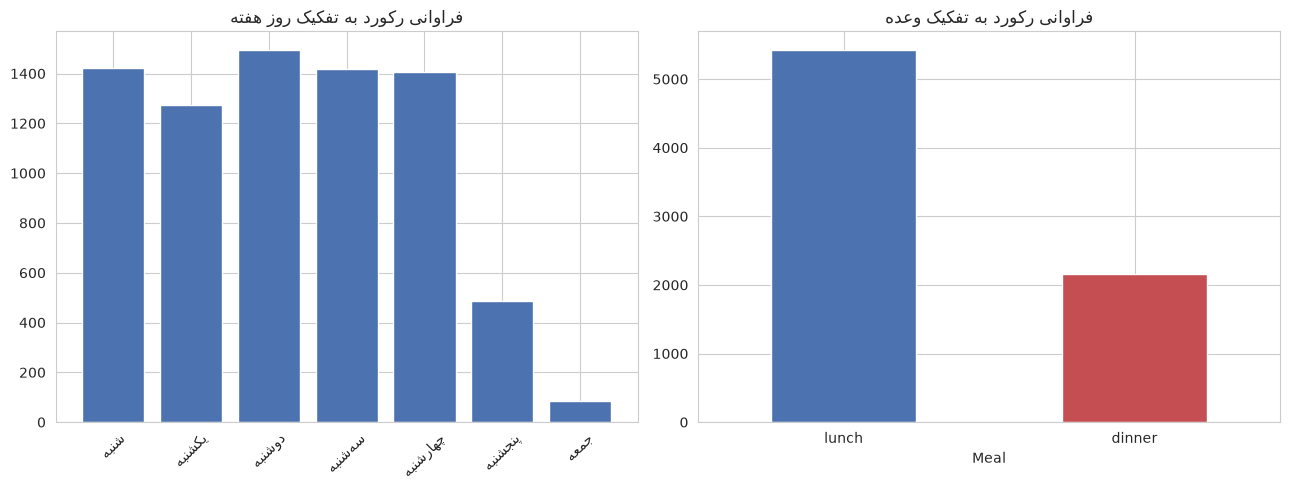

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar([fa(dow_map[i]) for i in dow_counts.index], dow_counts.values, color='#4C72B0')
axes[0].set_title(fa('فراوانی رکورد به تفکیک روز هفته'), fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

meal_counts.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#C44E52'])
axes[1].set_title(fa('فراوانی رکورد به تفکیک وعده'), fontsize=12)
axes[1].set_xticklabels(['lunch', 'dinner'], rotation=0)

fig.tight_layout()
save_fig(fig, '4.1_categorical_frequency.png', FIGURES_DIR)
plt.show()


### نمودار Pareto — سهم هر سلف از کل رزروها (Σ Res)

سهم ۳ سلف بزرگ (کوی, سطح شهر, کشاورزی) از کل Σ Res: 32.6%
تعداد سلف لازم برای پوشش ۸۰٪ کل Σ Res: 13 از 32 سلف (40.6٪ سلف‌ها)


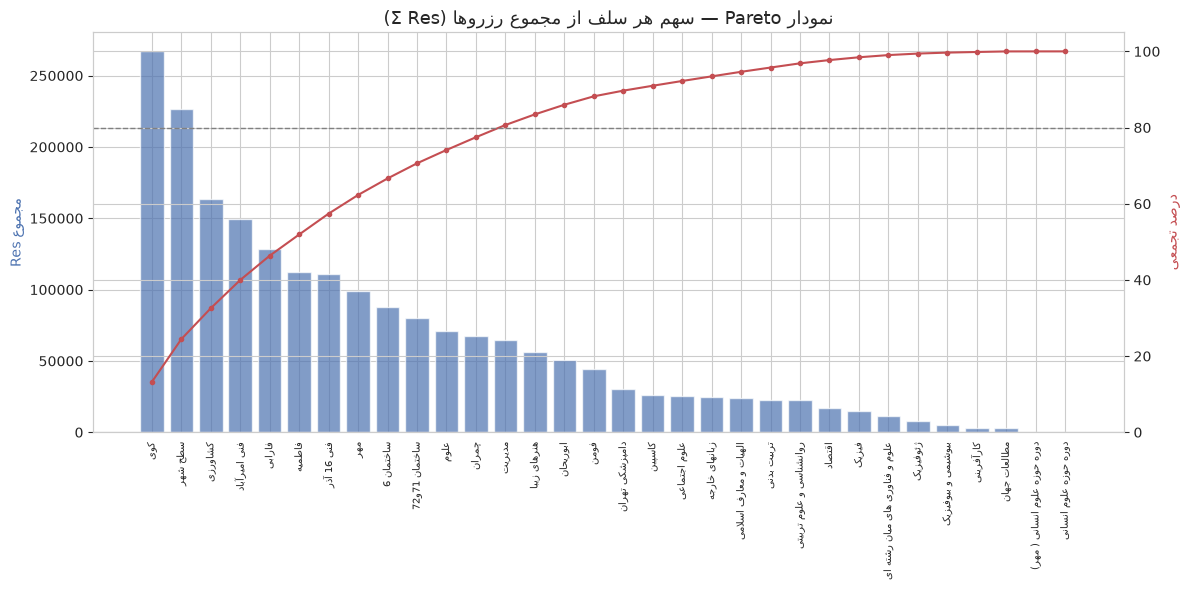

In [19]:
rest_total_res = df.groupby('RestaurantName')['Res'].sum().sort_values(ascending=False)
cum_pct = rest_total_res.cumsum() / rest_total_res.sum() * 100

n_for_80 = int((cum_pct <= 80).sum() + 1)
top3_pct = cum_pct.iloc[2]
print(f"سهم ۳ سلف بزرگ ({', '.join(rest_total_res.index[:3])}) از کل Σ Res: {top3_pct:.1f}%")
print(f"تعداد سلف لازم برای پوشش ۸۰٪ کل Σ Res: {n_for_80} از {len(rest_total_res)} سلف ({n_for_80/len(rest_total_res)*100:.1f}٪ سلف‌ها)")

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(range(len(rest_total_res)), rest_total_res.values, color='#4C72B0', alpha=0.7)
ax1.set_xticks(range(len(rest_total_res)))
ax1.set_xticklabels([fa(n) for n in rest_total_res.index], fontsize=7, rotation=90)
ax1.set_ylabel(fa('مجموع Res'), color='#4C72B0')

ax2 = ax1.twinx()
ax2.plot(range(len(cum_pct)), cum_pct.values, color='#C44E52', marker='o', markersize=3, linewidth=1.5)
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel(fa('درصد تجمعی'), color='#C44E52')
ax2.set_ylim(0, 105)

ax1.set_title(fa('نمودار Pareto — سهم هر سلف از مجموع رزروها (Σ Res)'), fontsize=13)
fig.tight_layout()
save_fig(fig, '4.1_res_pareto.png', FIGURES_DIR)
plt.show()


### جمع‌بندی ۴.۱.۳

- **عدم‌توازن سلف‌ها:** دو سلف («دوره حوزه علوم انسانی» و «دوره حوزه علوم انسانی (مهر)») هر کدام کمتر از ۱۰ رکورد دارند (خروجی کد بالا) — نمونه‌ی ناکافی برای هر مدل به‌تفکیک سلف؛ کاندید ادغام با سلف مشابه یا حذف از تحلیل‌های سطح-سلف.
- **نسبت ناهار/شام نامتوازن است** (خروجی کد بالا) و علتش صرفاً تصادفی نیست: دانشگاهی‌ها عمدتاً ناهار و خوابگاهی‌ها عمدتاً شام سرو می‌کنند (جدول متقاطع بالا) — این باید در فیچرسازی و ارزیابی مدل جداگانه لحاظ شود، نه یک متغیر دسته‌ای ساده.
- **پنجشنبه و جمعه** سهم بسیار کمتری از رکوردها دارند (تعطیلی/سرو محدود آخر هفته دانشگاهی) — طبق قاعده‌ی این پروژه، جمعه عملاً حاشیه‌ای است.
- **تمرکز جغرافیایی بالا:** تعداد کمی از ۳۲ سلف سهم عمده‌ی کل رزروها را می‌سازند (خروجی کد Pareto بالا) — از نظر روش‌شناسی به تصمیم global-vs-per-cluster (بند ۴.۶.۴) مرتبط است.

## جمع‌بندی نهایی بند ۴.۱

یافته‌های این نوت‌بوک با کد یکتا (F1.1 تا F1.x) در `doc/eda/round1/S1_univariate.md` مستند شده‌اند.